# Create database

In [ ]:
import json
import os

from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings
from tqdm import tqdm
import shutil
import os
from google.colab import files

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

embeddings = OllamaEmbeddings(model="qwen3-embedding")

vision_libraries = ["opencv", "open3d", "pcl"]
documents = []

for lib in vision_libraries:
    file_path = f"data/parsed/{lib}_chunks.json"

    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found. Skipping...")
        continue

    with open(file_path, "r", encoding="utf-8") as f:
        json_chunks = json.load(f)

    for chunk in tqdm(json_chunks, desc=f"Processing {lib} Documents"):
        parts = [chunk.get("dense_embedding_text") or (
            chunk.get("entity_name", "") + "\n" + chunk.get("description", "")
        )]
        if chunk.get("parameters"):
            parts.append("Parameters:\n" + chunk["parameters"])
        if chunk.get("returns"):
            parts.append("Returns:\n" + chunk["returns"])
        page_content = "\n\n".join(filter(None, parts))

        metadata = chunk.get("metadata", {}).copy()

        metadata["library"] = lib
        metadata["entity_name"] = chunk.get("entity_name", "")
        metadata["signature"] = chunk.get("signature", "")
        metadata["description"] = chunk.get("description", "")

        metadata["parameters"] = str(chunk.get("parameters", ""))
        metadata["returns"] = str(chunk.get("returns", ""))

        documents.append(Document(page_content=page_content, metadata=metadata))

if documents:
    print(f"Ingesting {len(documents)} total documents into Chroma...")
    vectorstore = Chroma.from_documents(
        documents=documents,
        embedding=embeddings,
        persist_directory="./vision_chroma_db",
    )
    print("Data successfully ingested!")
else:
    print("No documents were found to ingest.")


folder_path = '.'
zip_filename = 'vision_chroma_db.zip'

if os.path.exists(folder_path):
    print(f"Rozpoczynam kompresję folderu: {folder_path}...")

    shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', folder_path)

    print("Kompresja zakończona. Rozpoczynam pobieranie...")

    files.download(zip_filename)
else:
    print(f"BŁĄD: Folder {folder_path} nie został znaleziony. Sprawdź nazwę ścieżki.")


Processing pcl Documents: 100%|██████████| 27093/27093 [00:00<00:00, 63880.01it/s] 


Ingesting 54063 total documents into Chroma...
Data successfully ingested!


In [ ]:
import shutil
import os
from google.colab import files

# 1. Definiujemy ścieżki
folder_path = '.'
zip_filename = 'vision_chroma_db.zip'

# 2. Sprawdzamy, czy folder istnieje
if os.path.exists(folder_path):
    print(f"Rozpoczynam kompresję folderu: {folder_path}...")

    # Tworzenie archiwum ZIP
    shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', folder_path)

    print("Kompresja zakończona. Rozpoczynam pobieranie...")

    # 3. Pobieranie pliku na dysk lokalny
    files.download(zip_filename)
else:
    print(f"BŁĄD: Folder {folder_path} nie został znaleziony. Sprawdź nazwę ścieżki.")

Rozpoczynam kompresję folderu: ....
Kompresja zakończona. Rozpoczynam pobieranie...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
data = {
    "question": [
        # OpenCV
        "Which function in OpenCV should be used for edge detection using the Canny method?",
        "What is the purpose of the cv2.findContours function?",
        "How do you perform adaptive thresholding in OpenCV?",
        # "What is the difference between a Gaussian filter and a median filter?",
        "How do you convert the color space from BGR to Gray or HSV in OpenCV?",
        # "What is the SIFT (Scale-Invariant Feature Transform) algorithm used for?",
        "How do you perform a dilation operation on a binary image?",
        "How do you calculate an image histogram in OpenCV?",
        "What does the cv2.warpAffine function do?",
        "How do you implement object tracking using the MeanShift method?",
        # Open3D
        "How do you load a point cloud file (e.g., .pcd or .ply) in the Open3D library?",
        "How do you perform point cloud simplification using the Voxel Downsampling method?",
        # "What is the purpose of the ICP (Iterative Closest Point) algorithm in Open3D?",
        "How do you calculate surface normals for points in a cloud?",
        "How do you remove noise from a point cloud using the Statistical Outlier Removal method in Open3D?",
        # "How do you visualize a point cloud object in an interactive window?",
        "What is RANSAC in the context of plane segmentation in Open3D?",
        "How do you transform a point cloud using a 4x4 transformation matrix?",
        "How do you create a triangle mesh from a point cloud using the Ball Pivoting method in Open3D?",
        "How do you extract only the points located inside a specific Bounding Box?",
        # PCL
        "How does the PassThrough filter work in the PCL library?",
        "What is the purpose of the pcl::VoxelGrid class?",
        "How do you implement Euclidean Cluster Extraction segmentation?",
        # "What is the FPFH (Fast Point Feature Histograms) descriptor?",
        "How do you remove outliers using RadiusOutlierRemoval?",
        "What is the purpose of the pcl::SACSegmentation module in PCL?",
        "How do you merge two point clouds into one in PCL (C++)?",
        "What does the Moving Least Squares (MLS) algorithm do in PCL?",
        "How do you define a KDTree for fast neighbor searching in PCL?",
        # "What is the purpose of the NARF (Normally Aligned Radial Feature) descriptor?",
    ],
    "ground_truth": [
        # OpenCV
        "You should use the cv2.Canny() function, which takes the input image and two thresholds (threshold1 and threshold2) for the hysteresis procedure.",
        "The function is used to detect contours in a binary image. It returns a list of contours and their hierarchy, allowing for shape and object analysis.",
        "The cv2.adaptiveThreshold() function is used, which allows for calculating the threshold for small regions of the image, making it effective under varying lighting conditions.",
        # "A Gaussian filter reduces noise by weighted averaging of neighboring pixels, while a median filter replaces a pixel with the median of its neighborhood, which is better for removing salt-and-pepper noise.",
        "You should use the cv2.cvtColor(image, flag) function, where the flag is, for example, cv2.COLOR_BGR2GRAY or cv2.COLOR_BGR2HSV.",
        # "SIFT is used for detecting and describing local image features that are invariant to scale changes, rotation, and illumination changes.",
        "The cv2.dilate() function is used, which expands the bright areas of the image (objects) at the expense of darker ones using a structural element (kernel).",
        "The cv2.calcHist() function is used, which allows for counting the frequency of pixel values within specific ranges (bins).",
        "It is used to perform affine transformations on an image, such as translation, rotation, or scaling, based on a 2x3 transformation matrix.",
        "The cv2.meanShift() function should be used, which iteratively shifts a search window toward the direction of maximum probability density.",
        # Open3D
        "You should use the open3d.io.read_point_cloud('file_path') function, which returns a PointCloud class object.",
        "The voxel_down_sample(voxel_size) method is used, where points located within a single voxel are replaced by their average.",
        # "ICP is used for registration (alignment) of two point clouds by minimizing the distance between corresponding points to find the spatial transformation.",
        "You should call the estimate_normals() method, which estimates normals based on the local neighborhood of each point (e.g., using a KDTree).",
        "The remove_statistical_outlier() function is used, which removes points that are further from their neighbors than the allowed average distance.",
        # "The open3d.visualization.draw_geometries([pcd]) function is used for this purpose.",
        "RANSAC is an iterative method used by the segment_plane() function, which allows finding the mathematical plane model that best fits a set of points.",
        "The transform(matrix) method should be used, where the matrix contains rotation and translation information in homogeneous coordinates.",
        "The create_from_point_cloud_ball_pivoting() function is used, which requires previously calculated surface normals.",
        "The crop(bounding_box) method should be used, where the bounding box is defined as an AxisAlignedBoundingBox or OrientedBoundingBox object.",
        # PCL
        "The PassThrough filter allows for cutting off points whose coordinates in a chosen dimension (e.g., Z-axis) are outside a specified [min, max] range.",
        "This class is used for downsampling point clouds by creating a 3D grid and replacing all points in a voxel with their centroid.",
        "You should create a pcl::EuclideanClusterExtraction object, define a search tree (e.g., KdTree), and set the cluster tolerance distance.",
        # "It is a local feature descriptor representing the surface geometry around a point, used for matching and registering point clouds.",
        "This filter removes points that have fewer than a specified minimum number of neighbors within a given search radius.",
        "It is used for fitting geometric models (planes, spheres, cylinders) to a point cloud using Sample Consensus algorithms like RANSAC.",
        "This can be done using the += operator (e.g., cloud_a += cloud_b), which appends the points from one cloud to the end of the other.",
        "MLS is used for smoothing point clouds and improving normal vector estimation through local surface approximation using polynomials.",
        "The pcl::KdTreeFLANN<pcl::PointXYZ> class should be used, which enables fast K-nearest neighbor (KNN) searching.",
        # "It is a keypoint feature descriptor designed for point clouds from range sensors, taking object boundaries into account.",
    ]
}

# Configuration, downloading libraries

In [ ]:
!sudo apt-get update && sudo apt-get install zstd -y
!curl -fsSL https://ollama.com/install.sh | sh

import subprocess
import time

process = subprocess.Popen(['ollama', 'serve'], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

time.sleep(5)

!ollama pull gemma2:9b
!ollama pull qwen3-embedding

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,644 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,915 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,292 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,602 kB]
Get:13 http://archiv

In [ ]:
!nvidia-smi

Sat May 16 09:48:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install rank_bm25

In [50]:
!nohup ollama serve > ollama.log 2>&1 &

In [ ]:
!ollama list

NAME                      ID              SIZE      MODIFIED       
qwen3-embedding:latest    64b933495768    4.7 GB    6 seconds ago     
gemma2:9b                 ff02c3702f32    5.4 GB    35 seconds ago    


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

requirements_path = '/content/drive/My Drive/studia/NLP/requirements.txt'

In [ ]:
!pip install -r "$requirements_path"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 811.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72

In [ ]:
!ollama pull llama3.1:8b

# Evaluation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!cp "/content/drive/MyDrive/studia/NLP/vision_chroma_db.zip" .
import zipfile
with zipfile.ZipFile('vision_chroma_db.zip', 'r') as zip_ref:
    zip_ref.extractall('./vision_chroma_db')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import OllamaEmbeddings

full_path = os.path.abspath("./vision_chroma_db")

embeddings = OllamaEmbeddings(model="qwen3-embedding")

vectorstore = Chroma(
    persist_directory=full_path,
    embedding_function=embeddings,
    collection_name="langchain"
)

print(f"Liczba dokumentów przez LangChain: {vectorstore._collection.count()}")

/tmp/ipykernel_1988/3342944420.py:8: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import OllamaEmbeddings``.
  embeddings = OllamaEmbeddings(model="qwen3-embedding")
/tmp/ipykernel_1988/3342944420.py:10: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectorstore = Chroma(


Liczba dokumentów przez LangChain: 54063


In [47]:
import re

import ollama as _ollama
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_chroma import Chroma
from langchain_classic.retrievers import EnsembleRetriever
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_community.retrievers import BM25Retriever
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import OllamaEmbeddings
from langchain_ollama.llms import OllamaLLM


_COMPARATIVE_RE = re.compile(
    r"\b(difference|differ|compare|comparison|vs\.?|versus|contrast|"
    r"when to use|which is better|pros and cons)\b",
    re.IGNORECASE,
)
_BETWEEN_RE = re.compile(
    r"\bbetween\s+(.+?)\s+and\s+(.+?)(?:\?|$)", re.IGNORECASE
)

_SCORE_THRESHOLD = 0.5
_RERANKER_TOP_N = 3
_reranker = CrossEncoderReranker(
    model=HuggingFaceCrossEncoder(model_name="cross-encoder/ms-marco-MiniLM-L-6-v2"),
    top_n=_RERANKER_TOP_N,
)


def _bm25_text(meta: dict) -> str:
    parts = [
        meta.get("entity_name", ""),
        meta.get("signature", ""),
        meta.get("description", ""),
        meta.get("parameters", ""),
        meta.get("returns", ""),
    ]
    return " ".join(filter(None, parts))


def get_library_filter(user_prompt: str) -> dict:
    match = re.search(r"\b(opencv|open[- ]?3d|pcl)\b", user_prompt, re.IGNORECASE)

    if match:
        raw_match = match.group(1).lower()
        normalized_lib = raw_match.replace(" ", "").replace("-", "")

        return {"library": normalized_lib}
    return {}


def get_library_docs_for_bm25_search(vectorstore: Chroma, batch_size: int):
    all_documents_raw = []
    all_metadatas_raw = []
    offset = 0

    while True:
        batch = vectorstore.get(
            include=["documents", "metadatas"], limit=batch_size, offset=offset
        )

        if not batch["documents"]:
            break

        all_documents_raw.extend(batch["documents"])
        all_metadatas_raw.extend(batch["metadatas"])
        offset += batch_size

    all_docs = []
    library_docs = {"opencv": [], "open3d": [], "pcl": []}

    for doc, meta in zip(all_documents_raw, all_metadatas_raw):
        bm25_doc = Document(page_content=_bm25_text(meta), metadata=meta)
        all_docs.append(bm25_doc)
        lib = meta.get("library", "")
        if lib in library_docs:
            library_docs[lib].append(bm25_doc)

    return all_docs, library_docs

def _retrieve_docs(query: str, lib_filter: dict, k: int) -> list:
    candidate_k = max(k * 3, 20)
    search_kwargs = {"k": candidate_k, "score_threshold": _SCORE_THRESHOLD}
    if lib_filter:
        search_kwargs["filter"] = lib_filter
    dense = vectorstore.as_retriever(
        search_type="similarity_score_threshold", search_kwargs=search_kwargs
    )
    lib_key = lib_filter.get("library", "") if lib_filter else ""
    sparse = bm25_retrievers.get(lib_key) or bm25_retrievers["all"]
    sparse.k = candidate_k
    ensemble = EnsembleRetriever(retrievers=[dense, sparse], weights=[0.5, 0.5])
    compression_retriever = ContextualCompressionRetriever(
        base_compressor=_reranker, base_retriever=ensemble
    )
    return compression_retriever.invoke(query)


def retrieve_answer(question: str) -> str:

    dynamic_filter = get_library_filter(question)

    if dynamic_filter:
        print(f"Identified library filter: {dynamic_filter['library']}")
    else:
        print("No specific library identified.")

    if _COMPARATIVE_RE.search(question):
        between = _BETWEEN_RE.search(question)
        if between:
            term_a = between.group(1).strip()
            term_b = between.group(2).strip()
            print(f"[comparative] split retrieval: '{term_a}' vs '{term_b}'")
            docs_a = _retrieve_docs(term_a, dynamic_filter, k=4)
            docs_b = _retrieve_docs(term_b, dynamic_filter, k=4)
            seen, retrieved_docs = set(), []
            for doc in docs_a + docs_b:
                key = doc.metadata.get("entity_name", doc.page_content[:60])
                if key not in seen:
                    seen.add(key)
                    retrieved_docs.append(doc)
        else:
            retrieved_docs = _retrieve_docs(question, dynamic_filter, k=7)
    else:
        retrieved_docs = _retrieve_docs(question, dynamic_filter, k=7)

    formatted_docs = []
    for i, doc in enumerate(retrieved_docs):
        entity = doc.metadata.get("entity_name", "Unknown Entity")
        signature = doc.metadata.get("signature", "N/A")
        parameters = doc.metadata.get("parameters", "None provided.")
        returns = doc.metadata.get("returns", "None provided.")

        description = doc.metadata.get("description") or doc.page_content

        doc_string = f"""--- Document {i + 1}: {entity} ---
        Signature:
        {signature}

        Description:
        {description}

        Parameters:
        {parameters}

        Returns:
        {returns}
        """
        formatted_docs.append(doc_string)

    context_string = "\n".join(formatted_docs)

    result = chain.invoke({"docs": context_string, "question": question})
    return result, retrieved_docs

embeddings = OllamaEmbeddings(model="qwen3-embedding")

vectorstore = Chroma(
    persist_directory="./vision_chroma_db",
    embedding_function=embeddings,
)

model = OllamaLLM(model="llama3.1:8b", temperature=0.0)

template = """
You are an expert OpenCV, Open3D and PCL developer and technical documenter. Your job is to answer the user's question using ONLY the provided documentation context.

<rules>
1. STRICT GROUNDING: Base your answer on the provided `<context>`. You may synthesize and compare information across multiple documents to answer questions about differences, similarities, or relationships — as long as every claim is supported by at least one retrieved document. Class names, typedef names, and parameter descriptions are valid evidence — use them to infer purpose and behavior when no explicit definition is given.
2. MISSING INFO: Only reply "I cannot find the answer to this in the retrieved documentation." when the context contains NO relevant information at all — not even indirect clues like type names or parameter semantics. Do NOT refuse when the context contains relevant pieces that together answer the question through synthesis or reasonable inference. Never withhold a context-supported answer because you suspect a different or "better" function exists outside the provided context — answer with what is present.
3. NO META-TALK: Never say "Based on the provided snippets" or "The context shows". Just state the facts directly.
4. CODE FORMATTING: Use markdown formatting for all C++ signatures, function names, and code blocks.
5. CODE EXAMPLES: Only include a code snippet if the context contains an explicit example or a complete enough signature to reconstruct the call exactly. Do NOT invent code from memory.
6. CONCISENESS: Be precise and direct. Do not restate the question. Lead with the answer
   in a full sentence addressed to the user (e.g. "X is used for...", "X does...").
   Avoid filler phrases. Never copy raw documentation text verbatim as the answer.
7. NO OUTSIDE KNOWLEDGE: Do not add facts, behaviors, or examples that are not present in the provided context, even if you know them to be true.
8. CITATION: For every factual claim, mentally verify it appears in one of the documents above. If you cannot point to a specific document for a claim, omit the claim entirely.

</rules>

<context>
{docs}
</context>

Question: {question}
Answer:
"""
prompt = ChatPromptTemplate.from_template(template)
chain = prompt | model

all_docs, library_docs = get_library_docs_for_bm25_search(vectorstore, batch_size=5000)

bm25_retrievers = {
    "all": BM25Retriever.from_documents(all_docs),
    "opencv": BM25Retriever.from_documents(library_docs["opencv"])
    if library_docs["opencv"]
    else None,
    "open3d": BM25Retriever.from_documents(library_docs["open3d"])
    if library_docs["open3d"]
    else None,
    "pcl": BM25Retriever.from_documents(library_docs["pcl"])
    if library_docs["pcl"]
    else None,
}

for retriever in bm25_retrievers.values():
    if retriever:
        retriever.k = 7


# Generowanie odpowiedzi

In [51]:

from ragas import evaluate
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision
from langchain_community.chat_models import ChatOllama
from datasets import Dataset
from ragas.llms import llm_factory
from langchain_openai import OpenAIEmbeddings
from langchain_openai import ChatOpenAI
from openai import OpenAI
from google.colab import userdata
from ragas.embeddings import embedding_factory


data = {
    "question": [
    "What does cv::ximgproc::anisotropicDiffusion do, and what is the alpha parameter?",
    "What does cv::ximgproc::edgePreservingFilter do and what is the d parameter?",
    "What thresholding technique does cv::ximgproc::niBlackThreshold use?",
    "How does cv::cuda::LookUpTable::transform work?",
    "What does cv::FaceDetectorYN::setNMSThreshold do?",
    "What does cv::FaceDetectorYN::setScoreThreshold do?",
    "What does cv::MinProblemSolver::minimize do and what is the x parameter?",
    "What is cv::setOpenGlDrawCallback used for?",
    "What does cv::adaptiveThreshold do?",
    "What does cv::HoughLines do and what does the lines output contain?",
    "What does open3d.geometry.PointCloud.voxel_down_sample do?",
    "What algorithm does open3d.geometry.PointCloud.cluster_dbscan use, and what does a label of -1 indicate?",
    "What algorithm does open3d.t.geometry.PointCloud.segment_plane use?",
    "What does open3d.geometry.PointCloud.estimate_normals do?",
    "What does open3d.visualization.draw_geometries do?",
    "What does open3d.geometry.PointCloud.compute_point_cloud_distance compute?",
    "What does open3d.camera.PinholeCameraIntrinsic store?",
    "What is open3d.geometry.AxisAlignedBoundingBox and how is it generated?",
    "What does open3d.t.geometry.PointCloud.remove_statistical_outliers do?",
    "What does open3d.core.addmm compute?",
    "What does pcl::ApproximateVoxelGrid::setLeafSize do?",
    "What does pcl::StatisticalOutlierRemoval::setMeanK do?",
    "What does pcl::SACSegmentation::setMethodType do?",
    "What does pcl::PassThrough::setFilterFieldName do?",
    "What does pcl::gpu::EuclideanClusterExtraction::setClusterTolerance do?",
    "What does pcl::FPFHEstimation::computeFeature estimate?",
    "What does pcl::registration::TransformationEstimation estimate?",
    "What does pcl::RadiusOutlierRemoval::setMinNeighborsInRadius do?",
    "What does pcl::filters::Convolution3D::setRadiusSearch do?",
    "What does pcl::gpu::EuclideanClusterExtraction::extract do?"
  ],
  "ground_truth": [
    "cv::ximgproc::anisotropicDiffusion performs anisotropic diffusion on an image using the Perona-Malik method, which is the solution to a partial differential equation. It requires a source image with 3 channels and writes the result to a destination image of the same size. The alpha parameter controls the amount of time step per iteration.",
    "cv::ximgproc::edgePreservingFilter smoothes an image using the Edge-Preserving filter. It reduces both Gaussian noise and salt & pepper noise. The source must be an 8-bit 3-channel image. The d parameter is the diameter of each pixel neighborhood that is used during filtering.",
    "cv::ximgproc::niBlackThreshold performs thresholding using Niblack's technique or popular variations inspired by it. The function transforms a grayscale image to a binary image. It accepts an 8-bit single-channel source image and produces a destination image of the same size and type.",
    "cv::cuda::LookUpTable::transform transforms the source matrix into the destination matrix using the given look-up table, applying the formula dst(I) = lut(src(I)). Currently, CV_8UC1 and CV_8UC3 source matrices are supported. It also accepts an optional stream for asynchronous operation.",
    "cv::FaceDetectorYN::setNMSThreshold sets the Non-maximum-suppression threshold to suppress bounding boxes that have an IoU greater than the given value. The parameter nms_threshold specifies the threshold for the NMS operation.",
    "cv::FaceDetectorYN::setScoreThreshold sets the score threshold to filter out bounding boxes whose score is less than the given value. The parameter score_threshold specifies the threshold for filtering out bounding boxes.",
    "cv::MinProblemSolver::minimize actually runs the minimization algorithm. The x parameter is the initial point that becomes the centroid of the initial simplex. After the algorithm terminates, x will be set to the point where the minimum was found. The function returns the minimum value of the objective function.",
    "cv::setOpenGlDrawCallback sets a callback function to be called to draw on top of the displayed image. It can be used to draw 3D data on the window. The winname parameter specifies the target window, and onOpenGlDraw is a pointer to the function to be called every frame.",
    "cv::adaptiveThreshold applies an adaptive threshold to an array, transforming a grayscale image to a binary image. The function can process the image in-place. It requires an 8-bit single-channel source image and produces a destination image of the same size and type.",
    "cv::HoughLines finds lines in a binary image using the standard Hough transform algorithm. It requires an 8-bit single-channel binary source image. The lines parameter is an output vector where each line is represented by its detected parameters. The image may be modified by the function during processing.",
    "open3d.geometry.PointCloud.voxel_down_sample downsamples the input point cloud into an output point cloud using a voxel grid. If normals and colors exist in the input, they are averaged within each voxel.",
    "open3d.geometry.PointCloud.cluster_dbscan clusters a PointCloud using the DBSCAN algorithm by Ester et al. (1996), 'A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise'. It returns a list of point labels, where a label of -1 indicates noise according to the algorithm.",
    "open3d.t.geometry.PointCloud.segment_plane segments a plane in the point cloud using the RANSAC algorithm. It is a wrapper for a CPU implementation, and a copy of the point cloud data as well as the resulting plane model and inlier indices will be made.",
    "open3d.geometry.PointCloud.estimate_normals computes the normals of a point cloud. Normals are oriented with respect to the input point cloud if normals already exist in it.",
    "open3d.visualization.draw_geometries draws a list of geometry objects.",
    "open3d.geometry.PointCloud.compute_point_cloud_distance computes, for each point in the source point cloud, the distance to the target point cloud.",
    "open3d.camera.PinholeCameraIntrinsic stores the intrinsic camera matrix along with the image height and width.",
    "open3d.geometry.AxisAlignedBoundingBox is a class that defines an axis-aligned box that can be computed from 3D geometries. The bounding box is generated using the coordinate axes.",
    "open3d.t.geometry.PointCloud.remove_statistical_outliers removes points that are further away from their nb_neighbor neighbors in average. This function is not recommended to use on GPU.",
    "open3d.core.addmm performs the addmm operation on two 2D tensors with compatible shapes. Specifically, it returns output = alpha * A @ B + beta * input.",
    "pcl::ApproximateVoxelGrid::setLeafSize sets the voxel grid leaf size. It accepts the leaf size as an input parameter.",
    "pcl::StatisticalOutlierRemoval::setMeanK sets the number of nearest neighbors to use for mean distance estimation. The input parameter specifies the number of points to use for mean distance estimation.",
    "pcl::SACSegmentation::setMethodType sets the type of sample consensus method to use, as a user-given parameter. The method types are defined in method_types.h.",
    "pcl::PassThrough::setFilterFieldName provides the name of the field to be used for filtering data. In conjunction with setFilterLimits(), points having values outside the specified interval for this field will be discarded. The input parameter is the name of the field that will be used for filtering.",
    "pcl::gpu::EuclideanClusterExtraction::setClusterTolerance sets the spatial cluster tolerance as a measure in the L2 Euclidean space. The tolerance parameter defines the maximum distance between two points for them to be considered part of the same cluster.",
    "pcl::FPFHEstimation::computeFeature estimates the Fast Point Feature Histograms (FPFH) descriptors at a set of points given by setInputCloud() and setIndices(), using the surface in setSearchSurface() and the spatial locator in setSearchMethod(). The output is the point cloud model dataset containing the FPFH feature estimates.",
    "pcl::registration::TransformationEstimation estimates a rigid rotation transformation between a source and a target point cloud. It takes the source point cloud, a vector of indices describing the points of interest in the source cloud, and the target point cloud as inputs.",
    "pcl::RadiusOutlierRemoval::setMinNeighborsInRadius sets the number of neighbors that need to be present in order for a point to be classified as an inlier. The number of points within the radius set by setRadiusSearch() must be equal to or greater than this number. The default minimum is 1. The parameter is named min_pts.",
    "pcl::filters::Convolution3D::setRadiusSearch sets the sphere radius to be used for determining the nearest neighbors. The radius parameter specifies the maximum distance to consider a point a neighbor.",
    "pcl::gpu::EuclideanClusterExtraction::extract extracts clusters from a PointCloud given by setInputCloud() and setIndices(). The clusters parameter receives the resultant point clusters."
  ]  ,
    "answer": [],
    "contexts": []
,
}
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
api_key = os.environ.get("OPENAI_API_KEY")


embeddings = OpenAIEmbeddings(
    model="text-embedding-ada-002",
    openai_api_key=api_key
)

judge_llm = ChatOpenAI(
    model="gpt-4o-mini",
    openai_api_key=api_key,
    model_kwargs={"response_format": {"type": "json_object"}}
)
metrics = [
    Faithfulness(llm=judge_llm),
    AnswerRelevancy(llm=judge_llm, embeddings=embeddings),
    ContextPrecision(llm=judge_llm),
]

answers = []
contexts_list = []

questions = data["question"]
for question in questions:
    print(f"Question: {question}")
    answer, retrieved_docs = retrieve_answer(question)
    raw_contexts = [doc.page_content for doc in retrieved_docs]
    print(f"Answer: {answer}")
    print("End of answer.")
    answers.append(answer)
    contexts_list.append(raw_contexts)

data["answer"] = answers
data["contexts"] = contexts_list
dataset = Dataset.from_dict(data)



/tmp/ipykernel_1988/1769927429.py:2: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision
/tmp/ipykernel_1988/1769927429.py:2: DeprecationWarning: Importing AnswerRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerRelevancy
  from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision
/tmp/ipykernel_1988/1769927429.py:2: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextPrecision
  from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision


Question: What does cv::ximgproc::anisotropicDiffusion do, and what is the alpha parameter?
No specific library identified.
Answer: cv::ximgproc::anisotropicDiffusion performs Perona-Malik anisotropic diffusion on an image. The alpha parameter specifies the amount of time to step forward by on each iteration (normally, it's between 0 and 1).
End of answer.
Question: What does cv::ximgproc::edgePreservingFilter do and what is the d parameter?
No specific library identified.
Answer: The `cv::ximgproc::edgePreservingFilter` function smoothes an image using the Edge-Preserving filter. It smooths Gaussian noise as well as salt & pepper noise. The `d` parameter is the diameter of each pixel neighborhood that is used during filtering, and it must be greater or equal to 3.
End of answer.
Question: What thresholding technique does cv::ximgproc::niBlackThreshold use?
No specific library identified.
Answer: Niblack's technique is used by default, but other techniques can be specified using the `b

In [52]:
from ragas.run_config import RunConfig
results = evaluate(dataset, metrics=metrics, run_config=RunConfig(max_workers=3))
df = results.to_pandas()

Evaluating:   0%|          | 0/90 [00:00<?, ?it/s]

In [35]:
import json

json_string = json.dumps(data, indent=4, ensure_ascii=False)

print(json_string)

{
    "question": [
        "What does cv::ximgproc::anisotropicDiffusion do, and what is the alpha parameter?",
        "What does cv::ximgproc::edgePreservingFilter do and what is the d parameter?",
        "What thresholding technique does cv::ximgproc::niBlackThreshold use?",
        "How does cv::cuda::LookUpTable::transform work?",
        "What does cv::FaceDetectorYN::setNMSThreshold do?",
        "What does cv::FaceDetectorYN::setScoreThreshold do?",
        "What does cv::MinProblemSolver::minimize do and what is the x parameter?",
        "What is cv::setOpenGlDrawCallback used for?",
        "What does cv::adaptiveThreshold do?",
        "What does cv::HoughLines do and what does the lines output contain?",
        "What does open3d.geometry.PointCloud.voxel_down_sample do?",
        "What algorithm does open3d.geometry.PointCloud.cluster_dbscan use, and what does a label of -1 indicate?",
        "What algorithm does open3d.t.geometry.PointCloud.segment_plane use?",
      

In [36]:
print(contexts_list)

[["void cv::ximgproc::anisotropicDiffusion void cv::ximgproc::anisotropicDiffusion\n(\nInputArray   src ,\n\nOutputArray   dst ,\n\nfloat   alpha ,\n\nfloat   K ,\n\nint   niters \xa0)\n\nPython: cv.ximgproc.anisotropicDiffusion( src, alpha, K, niters[, dst] ) ->  dst #include < opencv2/ximgproc.hpp >\n\nPerforms anisotropic diffusion on an image.\n\nThe function applies Perona-Malik anisotropic diffusion to an image. This is the solution to the partial differential equation:\n\n\\[{\\frac  {\\partial I}{\\partial t}}={\\mathrm  {div}}\\left(c(x,y,t)\\nabla I\\right)=\\nabla c\\cdot \\nabla I+c(x,y,t)\\Delta I\\]\n\nSuggested functions for c(x,y,t) are:\n\n\\[c\\left(\\|\\nabla I\\|\\right)=e^{{-\\left(\\|\\nabla I\\|/K\\right)^{2}}}\\]\n\nor\n\n\\[ c\\left(\\|\\nabla I\\|\\right)={\\frac {1}{1+\\left({\\frac  {\\|\\nabla I\\|}{K}}\\right)^{2}}} \\] Parameters:\n  src: Source image with 3 channels.\n  dst: Destination image of the same size and the same number of channels as src .\n  a

In [37]:
df.head(n=31)

,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision
0,What does cv::ximgproc::anisotropicDiffusion d...,[void cv::ximgproc::anisotropicDiffusion void ...,The function `cv::ximgproc::anisotropicDiffusi...,cv::ximgproc::anisotropicDiffusion performs an...,1.000000,0.950190,1.000000
1,What does cv::ximgproc::edgePreservingFilter d...,[void cv::ximgproc::edgePreservingFilter void ...,The `cv::ximgproc::edgePreservingFilter` funct...,cv::ximgproc::edgePreservingFilter smoothes an...,1.000000,0.958061,1.000000
2,What thresholding technique does cv::ximgproc:...,[void cv::ximgproc::niBlackThreshold #include ...,Niblack's technique. \n\nThe function transfor...,cv::ximgproc::niBlackThreshold performs thresh...,1.000000,0.860850,1.000000
3,How does cv::cuda::LookUpTable::transform work?,[virtual void cv::cuda::LookUpTable::transform...,The `cv::cuda::LookUpTable::transform` functio...,cv::cuda::LookUpTable::transform transforms th...,0.750000,0.969708,1.000000
4,What does cv::FaceDetectorYN::setNMSThreshold do?,[virtual void cv::FaceDetectorYN::setNMSThresh...,Set the Non-maximum-suppression threshold to s...,cv::FaceDetectorYN::setNMSThreshold sets the N...,0.833333,0.799936,1.000000
5,What does cv::FaceDetectorYN::setScoreThreshol...,[virtual void cv::FaceDetectorYN::setScoreThre...,Set the score threshold to filter out bounding...,cv::FaceDetectorYN::setScoreThreshold sets the...,0.800000,0.855426,1.000000
6,What does cv::MinProblemSolver::minimize do an...,[virtual double cv::MinProblemSolver::minimize...,actually runs the algorithm and performs the m...,cv::MinProblemSolver::minimize actually runs t...,1.000000,0.774629,1.000000
7,What is cv::setOpenGlDrawCallback used for?,[void cv::setOpenGlDrawCallback #include < ope...,Sets a callback function to be called to draw ...,cv::setOpenGlDrawCallback sets a callback func...,1.000000,0.823928,1.000000
8,What does cv::adaptiveThreshold do?,[void cv::adaptiveThreshold #include < opencv2...,Applies an adaptive threshold to a grayscale i...,cv::adaptiveThreshold applies an adaptive thre...,1.000000,0.848370,1.000000
9,What does cv::HoughLines do and what does the ...,[static void cv::HoughLinesWithAccumulator Fin...,cv::HoughLines finds lines in a binary image u...,cv::HoughLines finds lines in a binary image u...,0.375000,0.936596,0.500000


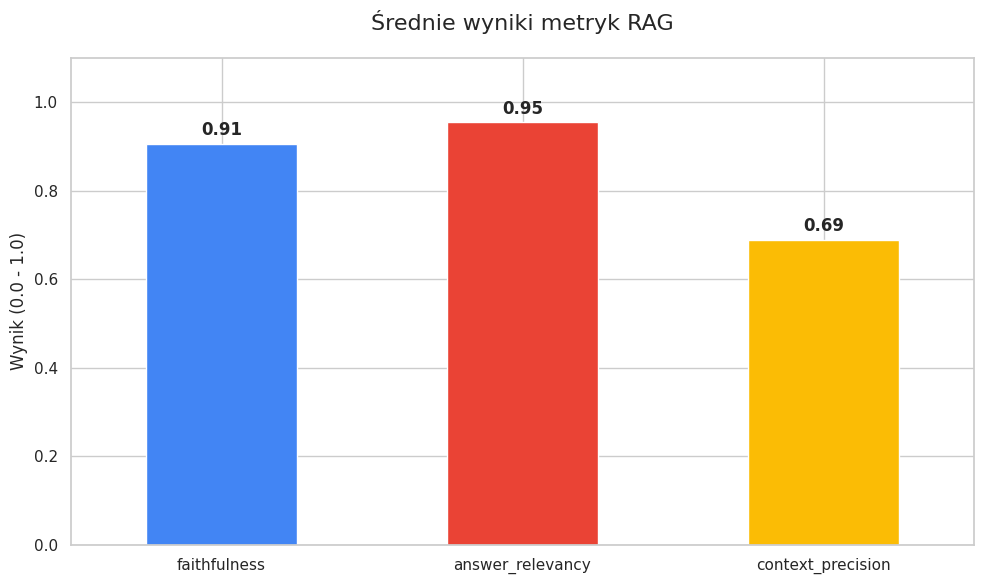

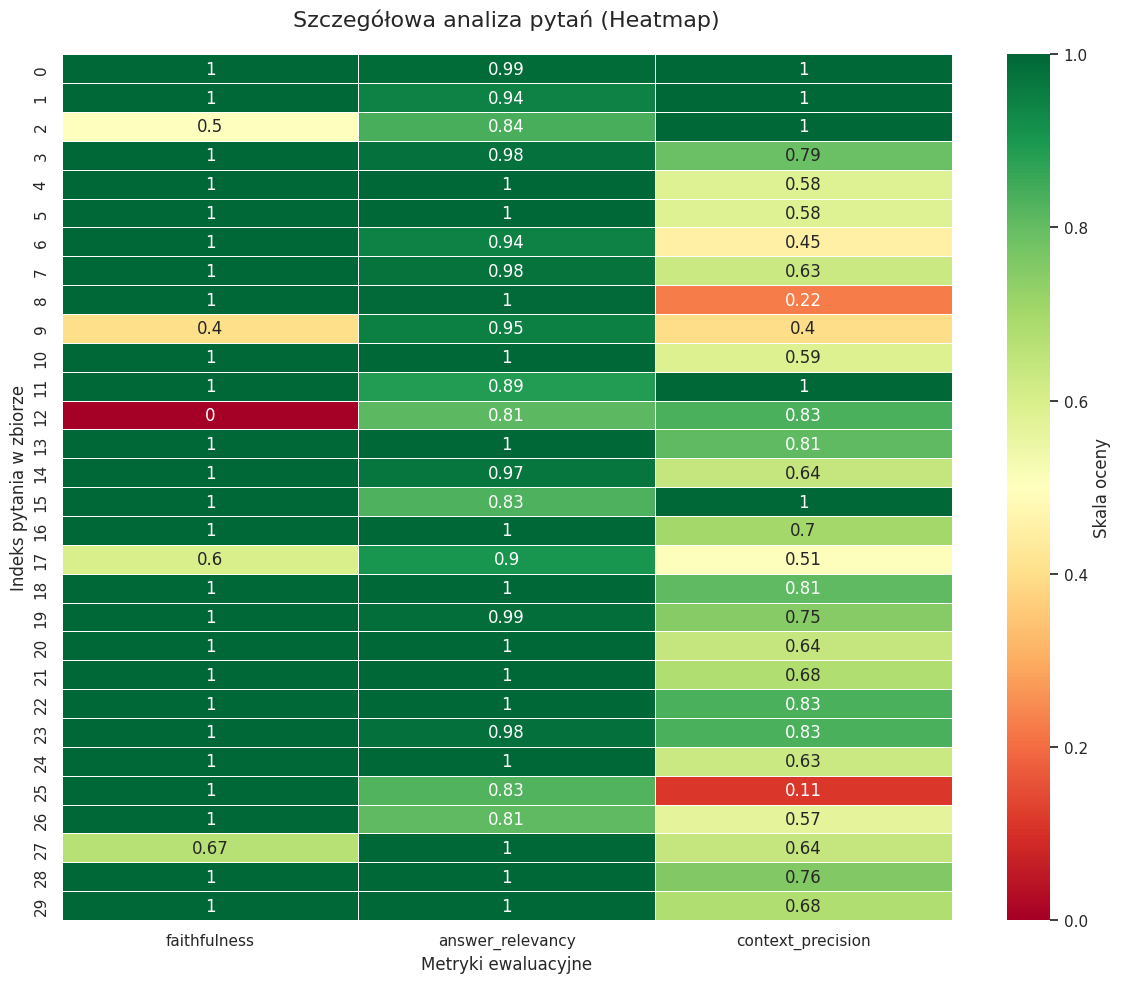

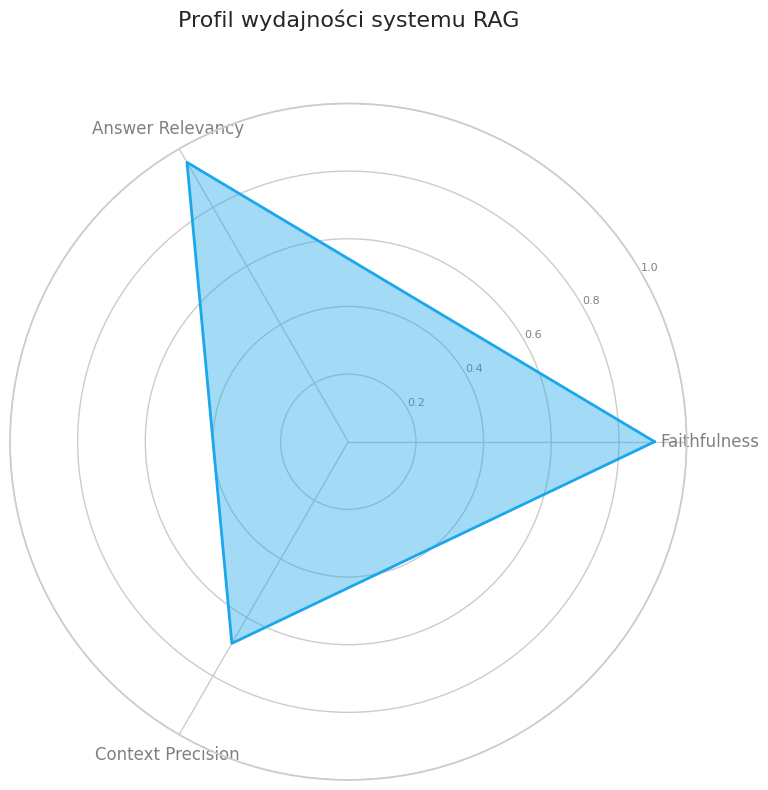

✅ Wszystkie wykresy zostały wygenerowane i zapisane jako pliki .png!


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

metrics_cols = ['faithfulness', 'answer_relevancy', 'context_precision']

plot_df = df[metrics_cols].fillna(0)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

plt.figure(figsize=(10, 6))
means = plot_df.mean()
ax = means.plot(kind='bar', color=['#4285F4', '#EA4335', '#FBBC05', '#34A853'][:len(metrics_cols)])

plt.title('Średnie wyniki metryk RAG', fontsize=16, pad=20)
plt.ylabel('Wynik (0.0 - 1.0)', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1.1)


for i, v in enumerate(means):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('rag_means.png')
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(plot_df, annot=True, cmap='RdYlGn', vmin=0, vmax=1, center=0.5,
            linewidths=.5, cbar_kws={'label': 'Skala oceny'})

plt.title('Szczegółowa analiza pytań (Heatmap)', fontsize=16, pad=20)
plt.xlabel('Metryki ewaluacyjne', fontsize=12)
plt.ylabel('Indeks pytania w zbiorze', fontsize=12)
plt.tight_layout()
plt.savefig('rag_heatmap.png')
plt.show()

labels = [c.replace('_', ' ').title() for c in metrics_cols]
stats = means.tolist()

angles = [n / float(len(labels)) * 2 * pi for n in range(len(labels))]
stats += stats[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
plt.xticks(angles[:-1], labels, color='grey', size=12)

ax.set_rlabel_position(30)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
plt.ylim(0, 1)

ax.plot(angles, stats, linewidth=2, linestyle='solid', color='#1AA7EC')
ax.fill(angles, stats, color='#1AA7EC', alpha=0.4)

plt.title('Profil wydajności systemu RAG', size=16, y=1.1)
plt.tight_layout()
plt.savefig('rag_radar.png')
plt.show()

print("✅ Wszystkie wykresy zostały wygenerowane i zapisane jako pliki .png!")

In [39]:
print(results)

{'faithfulness': 0.7434, 'answer_relevancy': 0.8501, 'context_precision': 0.9639}
